### 1 b) Simulación del desarrollo de la Hipertensión Arterial
A diferencia del envejecimiento (donde el factor dominante es la rigidez), la **hipertensión arterial** está gobernada principalmente por un aumento patológico en la resistencia al flujo sanguíneo debido a la vasoconstricción de las pequeñas arterias.

Para simular esto en el modelo $WK_2$:
* Aumentaremos fuertemente la **Resistencia Periférica ($R_P$)** (ej. un 70% por encima del valor basal).
* Reduciremos levemente la **Compliance ($C_A$)** (ej. un 20%) para contemplar el daño vascular asociado a la alta presión sostenida.

El resultado esperado es una elevación global de la curva de presión, afectando tanto la presión sistólica como la diastólica (aumento de la presión arterial media).

In [1]:
# -------------------------------------------------------------------------
# MÓDULOS DE USO GENERAL Y FUNCIÓN DE FLUJO (EXCITACIÓN)
# -------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def Q_Sim(Qmax, T, t):
    """
    Generación de una señal de FLUJO (Semiseno) similar al humano [ml/s]
    """
    Escala_ml = 1e5 * (Qmax / 8.8) # Ajuste a (500 ml/s)
    Q = Escala_ml * ((7.9853e-06 + 2.6617e-05*np.sin(2*np.pi*t/T+0.29498) +
                      2.3616e-05*np.sin(4*np.pi*t/T-1.1403) - 1.9016e-05*np.sin(6*np.pi*t/T+0.40435) -
                      8.5899e-06*np.sin(8*np.pi*t/T-1.1892) - 2.436e-06*np.sin(10*np.pi*t/T-1.4918) +
                      1.4905e-06*np.sin(12*np.pi*t/T+1.0536) + 1.3581e-06*np.sin(14*np.pi*t/T-0.47666) -
                      6.3031e-07*np.sin(16*np.pi*t/T+0.93768) - 4.5335e-07*np.sin(18*np.pi*t/T-0.79472) -
                      4.5184e-07*np.sin(20*np.pi*t/T-1.4095) - 5.6583e-07*np.sin(22*np.pi*t/T-1.3629) +
                      4.9522e-07*np.sin(24*np.pi*t/T+0.52495) + 1.3049e-07*np.sin(26*np.pi*t/T-0.97261) -
                      4.1072e-08*np.sin(28*np.pi*t/T-0.15685) - 2.4182e-07*np.sin(30*np.pi*t/T-1.4052) -
                      6.6217e-08*np.sin(32*np.pi*t/T-1.3785) - 1.5511e-07*np.sin(34*np.pi*t/T-1.2927) +
                      2.2149e-07*np.sin(36*np.pi*t/T+0.68178) + 6.7621e-08*np.sin(38*np.pi*t/T-0.98825) +
                      1.0973e-07*np.sin(40*np.pi*t/T+1.4327) - 2.5559e-08*np.sin(42*np.pi*t/T-1.2372) -
                      3.5079e-08*np.sin(44*np.pi*t/T+0.2328)))
    return Q

In [2]:
# -------------------------------------------------------------------------
# RESOLUCIÓN NUMÉRICA DEL MODELO WK2 (MÉTODO DE EULER)
# -------------------------------------------------------------------------

def resolver_wk2_euler(Q, t, Ca, Rp):
    """
    Resuelve la Ecuación Diferencial del Windkessel de 2 elementos
    dP/dt = Q/Ca - P/(Rp*Ca)
    """
    dt = t[1] - t[0]
    P = np.zeros(len(t))

    # Condición inicial
    P[0] = 80.0

    for i in range(1, len(t)):
        dP_dt = (Q[i-1] / Ca) - (P[i-1] / (Rp * Ca))
        P[i] = P[i-1] + (dP_dt * dt)

    return P

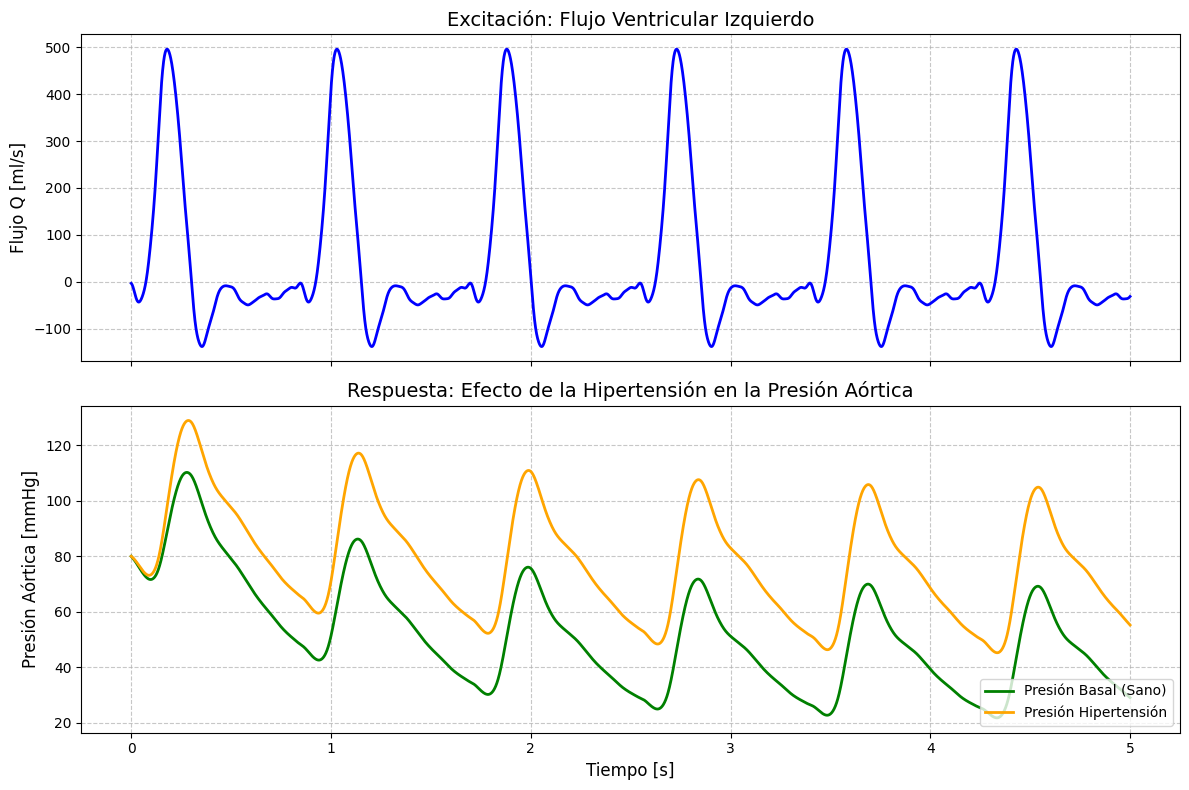

In [3]:
# -------------------------------------------------------------------------
# SIMULACIÓN 1b: HIPERTENSIÓN ARTERIAL
# -------------------------------------------------------------------------

# 1. Definición del vector de tiempo y flujo
Ts = 0.001
t = np.arange(0, 5, Ts)
T0 = 0.85
Qmax = 500

Q_entrada = Q_Sim(Qmax, T0, t)

# 2. Parámetros Fisiológicos Basales
Ca_basal = 1.1  # ml/mmHg
Rp_basal = 0.9  # mmHg·s/ml

# 3. Parámetros para Hipertensión (Aumento de Rp, leve caída de Ca)
Ca_hta = Ca_basal * 0.80
Rp_hta = Rp_basal * 1.70

# 4. Cálculo de las presiones
P_basal = resolver_wk2_euler(Q_entrada, t, Ca_basal, Rp_basal)
P_hta = resolver_wk2_euler(Q_entrada, t, Ca_hta, Rp_hta)

# 5. Visualización
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(t, Q_entrada, 'b', linewidth=2)
ax1.set_ylabel('Flujo Q [ml/s]', fontsize=12)
ax1.set_title('Excitación: Flujo Ventricular Izquierdo', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(t, P_basal, 'g', linewidth=2, label='Presión Basal (Sano)')
ax2.plot(t, P_hta, 'orange', linewidth=2, label='Presión Hipertensión')
ax2.set_xlabel('Tiempo [s]', fontsize=12)
ax2.set_ylabel('Presión Aórtica [mmHg]', fontsize=12)
ax2.set_title('Respuesta: Efecto de la Hipertensión en la Presión Aórtica', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Conclusión del análisis (1 b)
Observando los resultados gráficos, podemos extraer las siguientes conclusiones desde la fisiología y el procesamiento de señales:

1. **Desplazamiento del Nivel de DC (Presión Media):** A diferencia del envejecimiento sano donde la curva cambiaba su "forma" (mayor rizado), en la hipertensión el rasgo más notorio es que **toda la curva se desplaza hacia arriba**. Al aumentar significativamente la Resistencia Periférica ($R_P$), la componente continua de la señal se eleva. Fisiológicamente, esto significa que la presión diastólica (el punto más bajo del valle) es muy superior a los 80 mmHg normales, obligando al ventrículo izquierdo a vencer una postcarga mucho mayor para poder eyectar la sangre.
2. **Efecto de Filtro RC:** Desde el punto de vista circuital, aumentamos el resistor del filtro pasa bajos. La tensión en estado estacionario (Presión Media) es directamente el producto de la componente continua de corriente (Flujo Medio) por la resistencia ($P_{med} = Q_{med} \cdot R_P$).
3. **Impacto en la Amplitud (Presión de Pulso):** Aunque el efecto dominante es la elevación global, la reducción concurrente de la compliance ($C_A$) por el daño vascular provoca que la diferencia entre la presión sistólica (pico) y la diastólica (valle) también sea más amplia que en el caso basal.